<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/03_7_1_Randomized_SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Randomized SVD**

The code from the textbook [1] was modified to run on Google Colab.

[1] https://github.com/kursatkara/databook_python/blob/master/CH01/CH01_SEC08_RSVD.ipynb

In [50]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
import numpy as np

plt.rcParams.update({'font.size': 12})

# Define randomized SVD function
def rSVD(X,r,q,p):
    # Step 1: Sample column space of X with P matrix
    ny = X.shape[1]
    P = np.random.randn(ny,r+p)
    Z = X @ P
    for k in range(q):
        Z = X @ (X.T @ Z)

    Q, R = np.linalg.qr(Z,mode='reduced')

    # Step 2: Compute SVD on projected Y = Q.T @ X
    Y = Q.T @ X
    UY, S, VT = np.linalg.svd(Y,full_matrices=0)
    U = Q @ UY

    return U, S, VT

In [51]:
# Import the v2 API explicitly
import imageio.v2 as imageio

# Direct URL of the image
image_url = 'https://github.com/kursatkara/MAE_5020_S24/raw/master/Data/jupiter.jpg'

# Reading the image directly from the URL using the v2 API
A = imageio.imread(image_url)

X = np.mean(A,axis=2) # Convert RGB -> grayscale


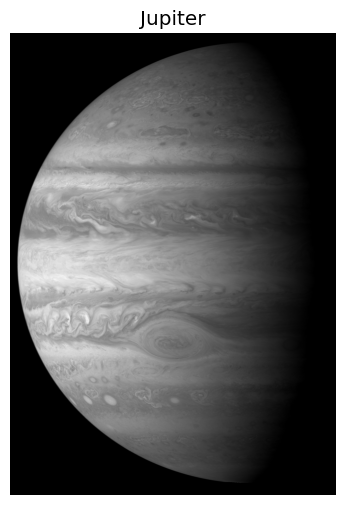

(3207, 2260) 7247820


In [52]:
# Plot the grayscale image
plt.imshow(X, cmap='gray')
plt.axis('off')
plt.title('Jupiter')
plt.show()
print(X.shape, X.size)

In [53]:
# Deterministic SVD
U, S, VT = np.linalg.svd(X,full_matrices=0)


In [54]:
#%timeit U, S, VT = np.linalg.svd(X,full_matrices=0)

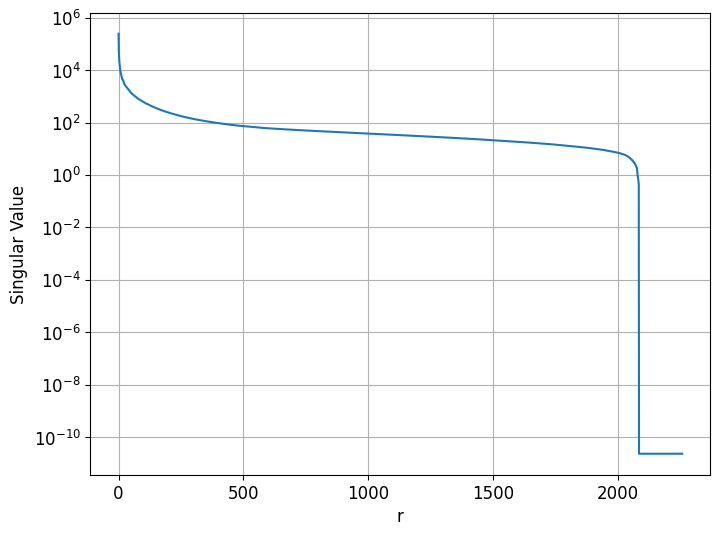

In [55]:
plt.rcParams['figure.figsize'] = [8,6]
plt.semilogy(S)
plt.xlabel('r')
plt.ylabel('Singular Value')
plt.grid()
plt.show()

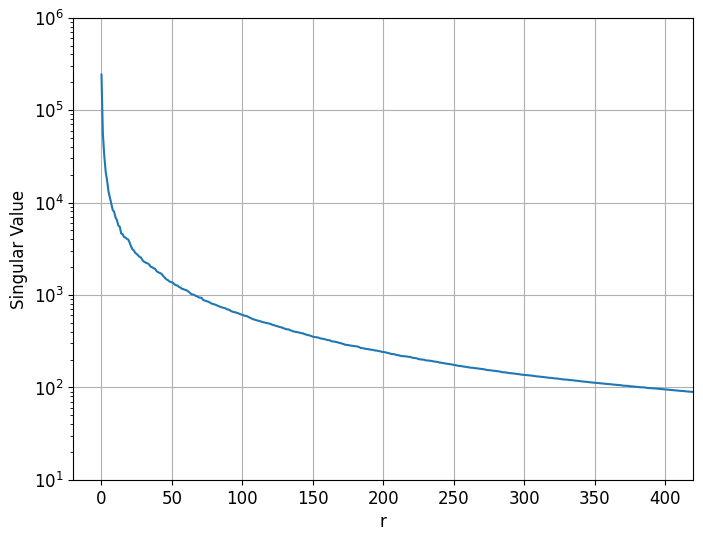

In [56]:
plt.rcParams['figure.figsize'] = [8,6]
plt.semilogy(S)
plt.xlabel('r')
plt.ylabel('Singular Value')
plt.xlim(-20,420)
plt.ylim(1e1,1e6)
plt.grid()
plt.show()

In [57]:
## Reconstruction using the regular SVD
r = 200 # Target rank

XSVD = U[:,:(r+1)] @ np.diag(S[:(r+1)]) @ VT[:(r+1),:] # SVD approximation


In [58]:
#%time XSVD = U[:,:(r+1)] @ np.diag(S[:(r+1)]) @ VT[:(r+1),:] # SVD approximation

In [59]:
errXSVD = np.linalg.norm(X-XSVD,ord=2) / np.linalg.norm(X,ord=2)
print(errXSVD)

0.000990556804001614


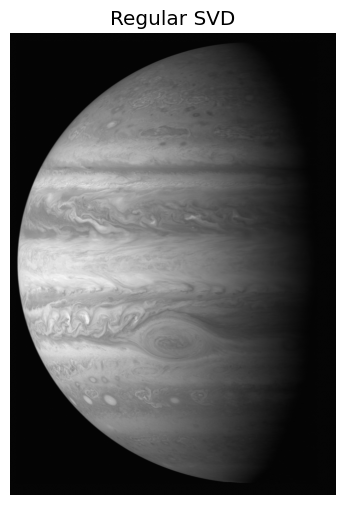

(3207, 2260) 7247820


In [60]:
# Plot the reconstruction using the regular SVD
plt.imshow(XSVD, cmap='gray')
plt.axis('off')
plt.title('Regular SVD')
plt.show()
print(XSVD.shape, XSVD.size)

In [61]:
# Randomized SVD
r = 200 # Target rank
q = 3   # Power iterations
p = 5   # Oversampling parameter

rU, rS, rVT = rSVD(X,r,q,p)

In [62]:
# %timeit rU, rS, rVT = rSVD(X,r,q,p)

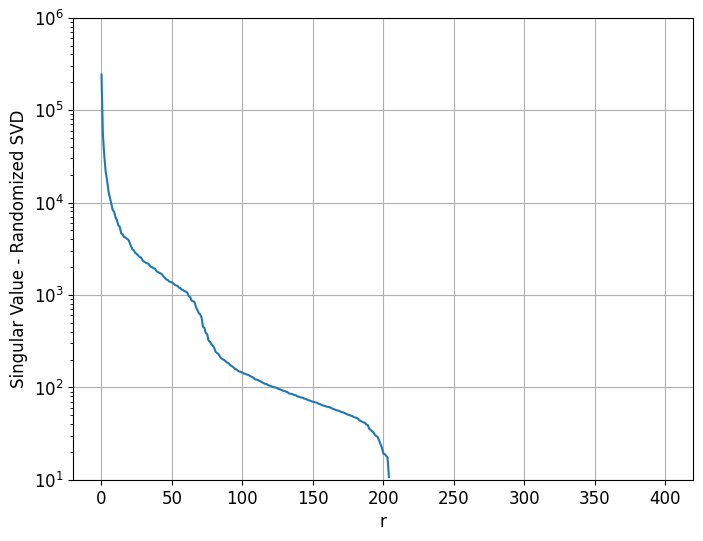

In [63]:
plt.rcParams['figure.figsize'] = [8,6]
plt.semilogy(rS)
plt.xlabel('r')
plt.ylabel('Singular Value - Randomized SVD')
plt.xlim(-20,420)
plt.ylim(1e1,1e6)
plt.grid()
plt.show()

In [64]:
## Reconstruction
XrSVD = rU[:,:(r+1)] @ np.diag(rS[:(r+1)]) @ rVT[:(r+1),:] # SVD approximation


In [65]:
%time XrSVD = rU[:,:(r+1)] @ np.diag(rS[:(r+1)]) @ rVT[:(r+1),:] # SVD approximation

CPU times: user 234 ms, sys: 14.9 ms, total: 249 ms
Wall time: 130 ms


In [66]:
errXrSVD = np.linalg.norm(X-XrSVD,ord=2) / np.linalg.norm(X,ord=2)
print(errXrSVD)

0.003382524326494129


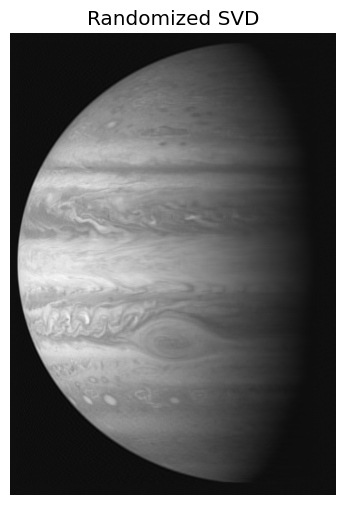

(3207, 2260) 7247820


In [67]:
# Plot the reconstruction using the randomized SVD
plt.imshow(XrSVD, cmap='gray')
plt.axis('off')
plt.title('Randomized SVD')
plt.show()
print(XrSVD.shape, XrSVD.size)

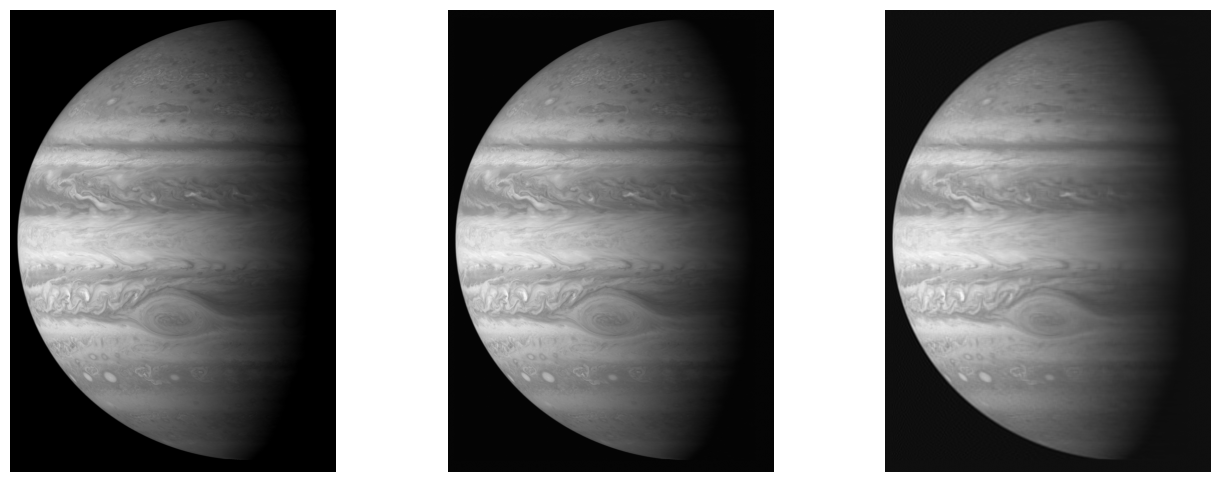

In [68]:
## Plot
plt.rcParams['figure.figsize'] = [16,6]
fig, axs = plt.subplots(1,3)

plt.set_cmap('gray')
axs[0].imshow(X)
axs[0].axis('off')
axs[1].imshow(XSVD)
axs[1].axis('off')
axs[2].imshow(XrSVD)
axs[2].axis('off')

plt.show()